Exploratory Data Analysis

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from lifelines import KaplanMeierFitter

sns.set_theme(style="whitegrid")


Load Data

In [2]:
data_candidates = [
    Path("../data/raw/telecom_churn_20000.csv"),
    Path("../data/raw/telecom_churn.csv"),
]

for candidate in data_candidates:
    if candidate.exists():
        data_path = candidate
        break
else:
    raise FileNotFoundError(f"Dataset not found. Checked: {data_candidates}")

df = pd.read_csv(data_path)
df.head()


,tenure,signup_date,last_active_days,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,...,TotalCharges,avg_monthly_usage,number_of_logins,complaints_count,customer_support_calls,late_payments,charges_per_month,tenure_group,engagement_score,Churn
0,53,2019-07-05,131,Female,0,No,No,Yes,Yes,Fiber optic,...,4957.77,77.7,16,5,5,1,93.54,Veteran,56.1,No
1,23,2022-01-08,106,Male,0,Yes,No,Yes,Yes,No,...,673.41,32.7,15,1,0,0,29.28,Regular,52.1,No
2,60,2018-12-25,3,Female,0,No,No,Yes,No,DSL,...,3834.64,61.8,11,2,4,0,63.91,Veteran,67.0,No
3,46,2020-02-01,44,Male,0,Yes,Yes,Yes,No,Fiber optic,...,3227.74,93.9,19,2,3,0,70.17,Loyal,67.0,No
4,3,2023-09-02,5,Female,0,No,No,Yes,No,Fiber optic,...,225.01,74.6,29,2,1,0,75.00,New,56.2,No


Convert Dates
Important for time analysis.

In [3]:
df["signup_date"] = pd.to_datetime(df["signup_date"])
df[["signup_date"]].dtypes


signup_date    datetime64[ns]
dtype: object

Basic Info

In [4]:
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   tenure                  20000 non-null  int64         
 1   signup_date             20000 non-null  datetime64[ns]
 2   last_active_days        20000 non-null  int64         
 3   gender                  20000 non-null  object        
 4   SeniorCitizen           20000 non-null  int64         
 5   Partner                 20000 non-null  object        
 6   Dependents              20000 non-null  object        
 7   PhoneService            20000 non-null  object        
 8   MultipleLines           20000 non-null  object        
 9   InternetService         20000 non-null  object        
 10  OnlineSecurity          20000 non-null  object        
 11  OnlineBackup            20000 non-null  object        
 12  DeviceProtection        20000 non-null  object

,tenure,signup_date,last_active_days,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,...,TotalCharges,avg_monthly_usage,number_of_logins,complaints_count,customer_support_calls,late_payments,charges_per_month,tenure_group,engagement_score,Churn
count,20000.000000,20000,20000.000000,20000,20000.000000,20000,20000,20000,20000,20000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000,20000.000000,20000
unique,NaN,NaN,NaN,2,NaN,2,2,2,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,2
top,NaN,NaN,NaN,Male,NaN,No,No,Yes,No,Fiber optic,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NaN,No
freq,NaN,NaN,NaN,10131,NaN,10362,14266,18084,10508,8655,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6314,NaN,14900
mean,30.880200,2021-05-20 23:06:12.960000,156.717950,NaN,0.161150,NaN,NaN,NaN,NaN,NaN,...,2116.317764,69.187995,17.449600,2.504450,3.567750,0.590200,68.537606,NaN,55.505650,NaN
min,0.000000,2017-12-02 00:00:00,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,...,0.000000,5.000000,3.000000,0.000000,0.000000,0.000000,17.810000,NaN,0.000000,NaN
25%,9.000000,2019-10-06 00:00:00,42.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,...,563.255000,55.100000,14.000000,1.000000,2.000000,0.000000,50.357500,NaN,46.200000,NaN
50%,29.000000,2021-07-20 00:00:00,149.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,...,1469.165000,69.100000,17.000000,2.000000,3.000000,0.000000,74.220000,NaN,55.600000,NaN
75%,50.000000,2023-03-08 00:00:00,258.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,...,3438.845000,83.400000,21.000000,4.000000,5.000000,1.000000,89.932500,NaN,65.000000,NaN
max,72.000000,2023-12-31 00:00:00,364.000000,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,...,8522.150000,150.000000,35.000000,10.000000,14.000000,5.000000,127.650000,NaN,100.000000,NaN


Target Analysis

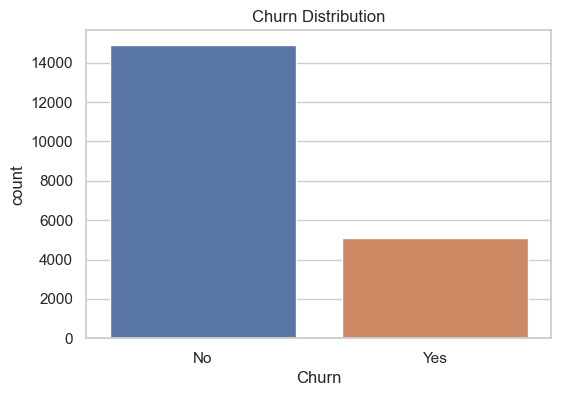

Dataset shows ~25.5% churn, confirming moderate class imbalance.


In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df, hue="Churn", legend=False)
plt.title("Churn Distribution")
plt.show()

churn_pct = df["Churn"].eq("Yes").mean() * 100
print(f"Dataset shows ~{churn_pct:.1f}% churn, confirming moderate class imbalance.")


Unique Behavioral Advantage

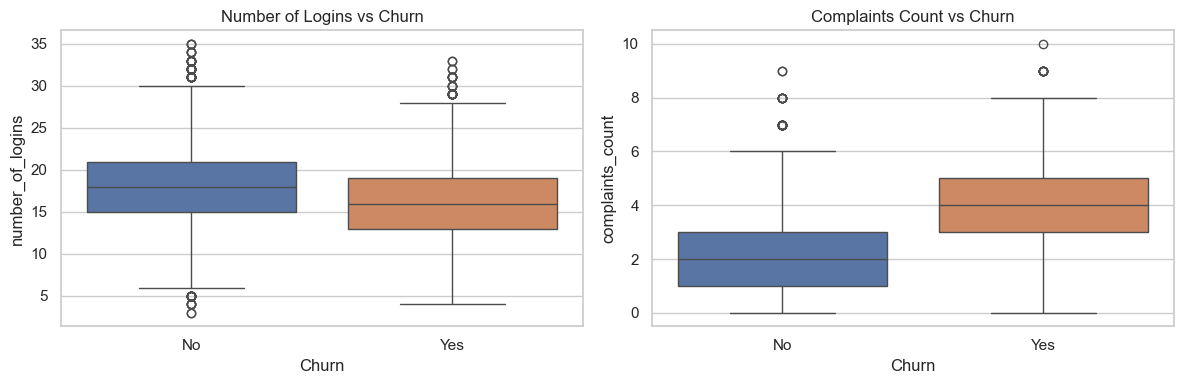

       number_of_logins  complaints_count
Churn                                    
No                 18.0               2.0
Yes                16.0               4.0
Insight: Customers with fewer logins and higher complaints churn more.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x="Churn", y="number_of_logins", data=df, ax=axes[0], hue="Churn", legend=False)
axes[0].set_title("Number of Logins vs Churn")
sns.boxplot(x="Churn", y="complaints_count", data=df, ax=axes[1], hue="Churn", legend=False)
axes[1].set_title("Complaints Count vs Churn")
plt.tight_layout()
plt.show()

behavior = df.groupby("Churn")[["number_of_logins", "complaints_count"]].median()
print(behavior)
print("Insight: Customers with fewer logins and higher complaints churn more.")


Engagement Analysis
This is a strong advantage over the classic IBM dataset.

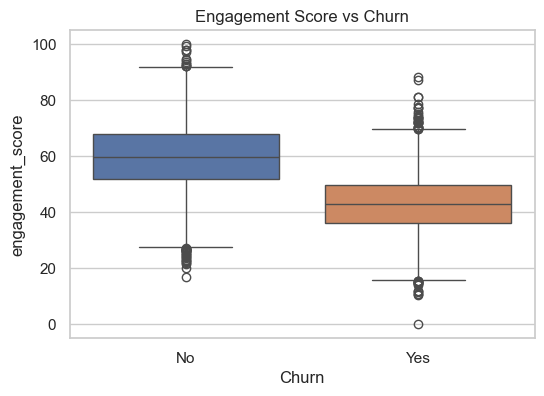

Churn
No     59.6
Yes    43.0
Name: engagement_score, dtype: float64


In [7]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="Churn", y="engagement_score", data=df, hue="Churn", legend=False)
plt.title("Engagement Score vs Churn")
plt.show()

engagement_summary = df.groupby("Churn")["engagement_score"].median()
print(engagement_summary)


Kaplan-Meier Survival

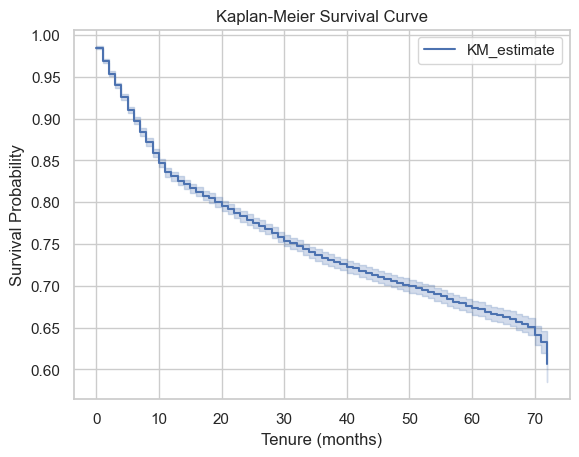

Survival at 12 months: 83.07 %
Insight: Early-stage customers show highest drop in survival probability.


In [8]:
kmf = KaplanMeierFitter()

df["ChurnBinary"] = df["Churn"].map({"Yes": 1, "No": 0})

kmf.fit(df["tenure"], event_observed=df["ChurnBinary"])
kmf.plot()
plt.title("Kaplan-Meier Survival Curve")
plt.xlabel("Tenure (months)")
plt.ylabel("Survival Probability")
plt.show()

print("Survival at 12 months:", round(float(kmf.predict(12)) * 100, 2), "%")
print("Insight: Early-stage customers show highest drop in survival probability.")


## Final Story
Customers with low engagement, high complaints, and flexible contracts are most likely to churn, especially in early lifecycle stages.
